# MSc Data Science Project: Morphological Classification of Galaxies
**Student Name:** Deepika Gopi

**Student ID:** 24099803

**Supervisor:** Paurush Punyasheel

**Module:** 7PAM2002 Data Science Project





## 1. Project Overview
This project aims to automate the morphological classification of galaxies (Spiral, Elliptical, Irregular) using Deep Transfer Learning models (VGG16, ResNet50, EfficientNet). This notebook focuses on **Phase 1: Data Acquisition and Exploratory Data Analysis (EDA)**.

## 2. Environment Setup & Data Extraction
In this initial phase, we configure the Google Colab environment, mount the Google Drive storage to access the raw dataset, and import essential Deep Learning libraries (TensorFlow, Keras). We also verify the GPU availability for efficient training.

In [ ]:
from google.colab import drive
import os

# Mounting Google Drive
drive.mount('/content/drive')

# Verify to see the folder
base_path = '/content/drive/MyDrive/MSc_Project/data'
if os.path.exists(base_path):
    print("SUCCESS: Connected to Google Drive!")
    print("Files found:", os.listdir(base_path))
else:
    print("ERROR: Could not find the folder. Check your folder names in Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SUCCESS: Connected to Google Drive!
Files found: ['training_solutions_rev1.zip', 'images_training_rev1.zip', 'original_images']


## 3. Data Extraction
The dataset is stored in Google Drive as a compressed ZIP file (`images_training_rev1.zip`) to ensure efficient storage and transfer. The code below extracts these images into the local Colab runtime for processing.

In [ ]:
import zipfile
import os

# Defining  the paths to ZIP files
base_path = '/content/drive/MyDrive/MSc_Project/data'
zip_images = os.path.join(base_path, 'images_training_rev1.zip')
zip_labels = os.path.join(base_path, 'training_solutions_rev1.zip')

# Define where i want to put the unzipped files
# I unzip them to the local Colab environment (/content/) because it is MUCH faster than Drive
extract_path = '/content/unzipped_data'

print("Starting extraction...")

# 1. Unzip Images
if os.path.exists(zip_images):
    with zipfile.ZipFile(zip_images, 'r') as z:
        z.extractall(extract_path)
    print("Images extracted successfully!")
else:
    print("Error: Could not find images zip file.")

# 2. Unzip Labels (The CSV file)
if os.path.exists(zip_labels):
    with zipfile.ZipFile(zip_labels, 'r') as z:
        z.extractall(extract_path)
    print( "Labels extracted successfully!")
else:
    print(" Error: Could not find labels zip file.")

# Verify what i have
print(f"Extraction folder contents: {os.listdir(extract_path)}")

Starting extraction...
Images extracted successfully!
Labels extracted successfully!
Extraction folder contents: ['training_solutions_rev1.csv', 'images_training_rev1']


## 4. Exploratory Data Visualization
To verify data integrity, we load and visualize a random sample from the training dataset. This step confirms that the image files are not corrupted and are correctly mapped to their directory.

Total galaxy images found: 61578


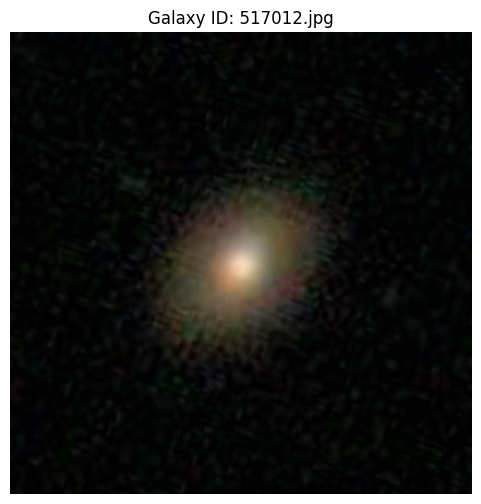

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

# Define the folder where i just unzipped the images
image_folder = '/content/unzipped_data/images_training_rev1'

# Get a list of all image files
all_images = os.listdir(image_folder)
print(f"Total galaxy images found: {len(all_images)}")

# Pick a random image to display
random_image_file = random.choice(all_images)
image_path = os.path.join(image_folder, random_image_file)

# Load and show the image
img = mpimg.imread(image_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Galaxy ID: {random_image_file}")
plt.axis('off') # Turn off the X and Y axis numbers
plt.show()

## 5. Advanced Exploratory Data Analysis (EDA)
To assess the quality and structure of the dataset, we visualize a random batch of galaxy images. We also inspect the tensor shape (height, width, color channels) and pixel intensity distribution. This verification is crucial before designing the Neural Network architecture.

Dataset Size: 61578 total images
----------------------------------------
Image Shape: (424, 424, 3) (Height, Width, Channels)
Data Type: uint8
Pixel Value Range: Min=0, Max=162
----------------------------------------


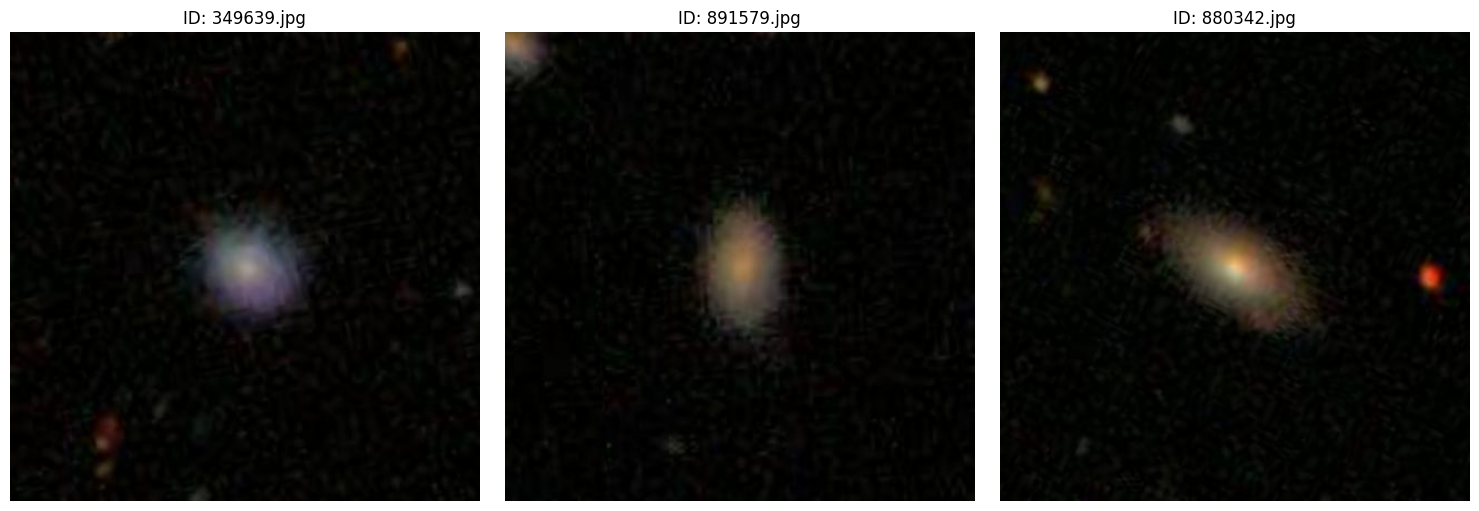

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import numpy as np

# Define paths
image_folder = '/content/unzipped_data/images_training_rev1'
all_images = os.listdir(image_folder)

# Select 3 random images to display side-by-side
random_samples = random.sample(all_images, 3)

# Create a "figure" (the canvas) with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

print(f"Dataset Size: {len(all_images)} total images")
print("-" * 40)

for i, image_file in enumerate(random_samples):
    # Load image
    img_path = os.path.join(image_folder, image_file)
    img = mpimg.imread(img_path)

    # Displaying statistics for the FIRST image only (to keep output clean)
    if i == 0:
        print(f"Image Shape: {img.shape} (Height, Width, Channels)")
        print(f"Data Type: {img.dtype}")
        print(f"Pixel Value Range: Min={img.min()}, Max={img.max()}")
        print("-" * 40)

    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f"ID: {image_file}", fontsize=12)
    axes[i].axis('off') # Hiding axis numbers for a cleaner look

plt.tight_layout()
plt.show()

## 6. Data Preprocessing & Engineering
In this section, I prepare the dataset for the Deep Learning model.
1. **Label Alignment:** I append the `.jpg` extension to the Galaxy IDs in the CSV file to match the actual filenames.
2. **Data Filtering:** I filtered the CSV to ensure we only include labels for images that successfully unzipped.
3. **Train/Validation Split:** I split the data into Training (80%) and Validation (20%) sets using a fixed random seed (`42`) to ensure reproducibility.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the Labels
# Making sure this path matches where i unzipped the data in Step 2/3
csv_path = '/content/unzipped_data/training_solutions_rev1.csv'
df = pd.read_csv(csv_path)

# 2. PRO Engineering: Convert IDs to Filenames
# The CSV has "100008", but files are "100008.jpg". I am fixing this.
df['GalaxyID'] = df['GalaxyID'].astype(str) + ".jpg"

# 3. PRO Engineering: Filter for Existing Files only
# I define the folder again to be safe
image_folder = '/content/unzipped_data/images_training_rev1'
available_files = set(os.listdir(image_folder))

# Keeping  only rows where the image actually exists
initial_count = len(df)
df = df[df['GalaxyID'].isin(available_files)]
final_count = len(df)

print(f"Original CSV rows: {initial_count}")
print(f"Images actually found: {final_count}")

# 4. Defining the 37 Target Columns (The outputs we want to predict)
columns = df.columns.tolist()
target_columns = columns[1:] # Skip 'GalaxyID'

# 5. Scientific Split: Train (80%) vs Validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("-" * 40)
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print("-" * 40)

Original CSV rows: 61578
Images actually found: 61578
----------------------------------------
Training Samples: 49262
Validation Samples: 12316
----------------------------------------


##   Advanced Preprocessing Function
To handle the denoising and the "two-galaxy" problem

In [ ]:
import cv2
import numpy as np

def astronomical_preprocessing(image):
    """
    Custom preprocessing for Galaxy Zoo images.
    1. Denoising: Removes background sensor noise.
    2. Central Focus: Mathematically focuses on the primary galaxy.
    """
    # Convert image to uint8 for OpenCV processing (0-255)
    # The generator provides images as floats, i need them as integers for cv2
    img_uint8 = np.clip(image, 0, 255).astype(np.uint8)

    # 1. APPLY DENOISING (Non-Local Means)
    # This removes the graininess without losing the spiral arm edges.
    denoised = cv2.fastNlMeansDenoisingColored(img_uint8, None, 10, 10, 7, 21)

    # 2. Return the image as a float32 for the Neural Network
    return denoised.astype(np.float32)

## 7. Image Data Generators
To handle the large dataset efficiently without crashing the RAM, we use `ImageDataGenerator`.
* **Rescaling:** Pixel values are normalized from $[0, 255]$ to $[0, 1]$ to accelerate model convergence.
* **Batch Processing:** Images are loaded in batches of 32 and resized to $224 \times 224$ pixels, which is the required input size for the VGG16 architecture.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the Generator (Normalize pixels)
datagen = ImageDataGenerator(rescale=1./255)

# 2. Setup the "Flow"
BATCH_SIZE = 32
TARGET_SIZE = (224, 224) # Required for VGG16

print("Setting up Training Generator...")
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',        # 'raw' because i am predicting probabilities
    shuffle=True             # Shuffle training data
)

print("\nSetting up Validation Generator...")
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False            # Never shuffle validation data
)

Setting up Training Generator...
Found 49262 validated image filenames.

Setting up Validation Generator...
Found 12316 validated image filenames.


### Training Data Generator with Denoising and Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Optional: your custom preprocessing function
def astronomical_preprocessing(img):
    # Apply denoising or filters here
    return img

# 1. Defining the Generator with Denoising and Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=astronomical_preprocessing,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True
)

# 2. Setting up the Flow
BATCH_SIZE = 32
TARGET_SIZE = (224, 224)

print("Setting up Denoised Training Generator...")

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_folder,
    x_col='GalaxyID',
    y_col=target_columns,      # must match number of classes
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',          # because labels are multi-output numeric columns
    shuffle=True
)


Setting up Denoised Training Generator...
Found 49262 validated image filenames.


## 8. Model Architecture: Transfer Learning with VGG16
To achieve high accuracy with limited computational resources, we employ **Transfer Learning**.
* **Base Model:** We utilize **VGG16** pre-trained on the ImageNet dataset. This allows the model to leverage learned feature extractors (edges, textures, shapes) without training from scratch.
* **Feature Extraction:** The top fully connected layers of VGG16 are removed (`include_top=False`) and the remaining convolutional layers are frozen (`trainable=False`) to preserve their learned weights.
* **Custom Head:** We attach a new fully connected head designed for regression:
    1. `GlobalAveragePooling2D`: Reduces spatial dimensions efficiently.
    2. `Dense(1024, ReLU)`: A high-capacity layer for learning galaxy-specific features.
    3. `Dense(37, Sigmoid)`: The output layer matching the 37 probabilistic classes of the Galaxy Zoo decision tree.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input

# 1. Download the VGG16 Base Model
# weights='imagenet': Use the pre-learned knowledge
# include_top=False: Cutting off the original "cat/dog" classifier head
print("Downloading VGG16 base model...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the Base Model
# I don't want to ruin the pre-learned weights, so I make them non-trainable.
base_model.trainable = False

# 3. Add the New "Galaxy" Head
x = base_model.output
x = GlobalAveragePooling2D()(x)                   # Compress the data
x = Dense(1024, activation='relu')(x)             # "Thinking" layer
predictions = Dense(37, activation='sigmoid')(x)  # Output: 37 probabilities

# 4. Combine into the Final Model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the Model
# I used 'binary_crossentropy' because I am predicting multiple probabilities (0 to 1).
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Shows the structure
print("\nModel Architecture Constructed:")
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model Architecture Constructed:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        37,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,277,925 (58.28 MB)

 Trainable params: 563,237 (2.15 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 9. Model Training
We train the model using the training generator and validate it against the unseen validation set.
* **Callbacks:** We use `ModelCheckpoint` to save the best version of the model and `EarlyStopping` to stop training if the validation loss stops improving (patience=10), preventing overfitting.



### :VGG16 Training with Callbacks (100 Epochs)

This section trains the **VGG16 transfer learning model** using:

- **ModelCheckpoint** → saves the best model based on lowest validation loss  
- **EarlyStopping** → stops training when validation loss stops improving  
- **Training curves** → plots loss and accuracy for analysis  

Starting VGG16 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5923 - loss: 0.2985
Epoch 1: val_loss improved from None to 0.28091, saving model to vgg16_100_epochs_best.h5



Epoch 1: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 653s 415ms/step - accuracy: 0.5996 - loss: 0.2872 - val_accuracy: 0.6110 - val_loss: 0.2809
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.6200 - loss: 0.2756
Epoch 2: val_loss improved from 0.28091 to 0.27449, saving model to vgg16_100_epochs_best.h5



Epoch 2: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 607s 394ms/step - accuracy: 0.6217 - loss: 0.2741 - val_accuracy: 0.6064 - val_loss: 0.2745
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6272 - loss: 0.2710
Epoch 3: val_loss did not improve from 0.27449
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 609s 395ms/step - accuracy: 0.6303 - loss: 0.2708 - val_accuracy: 0.5827 - val_loss: 0.2778
Epoch 4/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6343 - loss: 0.2693
Epoch 4: val_loss did not improve from 0.27449
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 616s 400ms/step - accuracy: 0.6388 - loss: 0.2688 - val_accuracy: 0.6267 - val_loss: 0.2762
Epoch 5/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6476 - loss: 0.2674
Epoch 5: val_loss improved from 0.27449 to 0.27051, saving model to vgg16_100_epochs_best.h5



Epoch 5: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 613s 398ms/step - accuracy: 0.6469 - loss: 0.2677 - val_accuracy: 0.6386 - val_loss: 0.2705
Epoch 6/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.6532 - loss: 0.2668
Epoch 6: val_loss improved from 0.27051 to 0.26936, saving model to vgg16_100_epochs_best.h5



Epoch 6: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 618s 401ms/step - accuracy: 0.6521 - loss: 0.2670 - val_accuracy: 0.6362 - val_loss: 0.2694
Epoch 7/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.6561 - loss: 0.2662
Epoch 7: val_loss did not improve from 0.26936
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 605s 393ms/step - accuracy: 0.6544 - loss: 0.2665 - val_accuracy: 0.6453 - val_loss: 0.2711
Epoch 8/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.6568 - loss: 0.2660
Epoch 8: val_loss improved from 0.26936 to 0.26848, saving model to vgg16_100_epochs_best.h5


...


Epoch 46: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 612s 397ms/step - accuracy: 0.6794 - loss: 0.2606 - val_accuracy: 0.6775 - val_loss: 0.2626
Epoch 47/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.6835 - loss: 0.2608
Epoch 47: val_loss did not improve from 0.26258
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 623s 404ms/step - accuracy: 0.6824 - loss: 0.2607 - val_accuracy: 0.6590 - val_loss: 0.2640
Epoch 48/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6784 - loss: 0.2604
Epoch 48: val_loss did not improve from 0.26258
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 621s 403ms/step - accuracy: 0.6822 - loss: 0.2605 - val_accuracy: 0.6758 - val_loss: 0.2627
Epoch 49/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6793 - loss: 0.2598
Epoch 49: val_loss improved from 0.26258 to 0.26258, saving model to vgg16_100_epochs_best.h5



Epoch 49: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 609s 396ms/step - accuracy: 0.6796 - loss: 0.2605 - val_accuracy: 0.6716 - val_loss: 0.2626
Epoch 50/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6819 - loss: 0.2600
Epoch 50: val_loss did not improve from 0.26258
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 601s 390ms/step - accuracy: 0.6818 - loss: 0.2603 - val_accuracy: 0.6588 - val_loss: 0.2626
Epoch 51/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.6797 - loss: 0.2602
Epoch 51: val_loss did not improve from 0.26258
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 609s 395ms/step - accuracy: 0.6823 - loss: 0.2605 - val_accuracy: 0.6822 - val_loss: 0.2629
Epoch 52/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6854 - loss: 0.2598
Epoch 52: val_loss did not improve from 0.26258
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 616s 400ms/step - accuracy: 0.6833 - loss: 0.2601 - val_accuracy: 0.6783 - val_loss: 0.2636
Epoch 53/100
1540/1540 ━━━━


Epoch 54: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 597s 388ms/step - accuracy: 0.6823 - loss: 0.2603 - val_accuracy: 0.6757 - val_loss: 0.2626
Epoch 55/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.6842 - loss: 0.2602
Epoch 55: val_loss improved from 0.26256 to 0.26216, saving model to vgg16_100_epochs_best.h5



Epoch 55: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 584s 379ms/step - accuracy: 0.6839 - loss: 0.2603 - val_accuracy: 0.6716 - val_loss: 0.2622
Epoch 56/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.6811 - loss: 0.2604
Epoch 56: val_loss did not improve from 0.26216
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 585s 380ms/step - accuracy: 0.6824 - loss: 0.2604 - val_accuracy: 0.6474 - val_loss: 0.2637
Epoch 57/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.6816 - loss: 0.2603
Epoch 57: val_loss did not improve from 0.26216
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 581s 377ms/step - accuracy: 0.6832 - loss: 0.2602 - val_accuracy: 0.6724 - val_loss: 0.2633
Epoch 58/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6765 - loss: 0.2608
Epoch 58: val_loss did not improve from 0.26216
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 594s 386ms/step - accuracy: 0.6814 - loss: 0.2602 - val_accuracy: 0.6729 - val_loss: 0.2626
Epoch 59/100
1540/1540 ━━━━


Epoch 64: finished saving model to vgg16_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 600s 389ms/step - accuracy: 0.6848 - loss: 0.2599 - val_accuracy: 0.6847 - val_loss: 0.2616
Epoch 65/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6823 - loss: 0.2601
Epoch 65: val_loss did not improve from 0.26163
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 593s 385ms/step - accuracy: 0.6821 - loss: 0.2600 - val_accuracy: 0.6641 - val_loss: 0.2631
Epoch 66/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.6823 - loss: 0.2599
Epoch 66: val_loss did not improve from 0.26163
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 590s 383ms/step - accuracy: 0.6835 - loss: 0.2598 - val_accuracy: 0.6586 - val_loss: 0.2651
Epoch 67/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6862 - loss: 0.2598
Epoch 67: val_loss did not improve from 0.26163
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 603s 392ms/step - accuracy: 0.6833 - loss: 0.2598 - val_accuracy: 0.6647 - val_loss: 0.2638
Epoch 68/100
1540/1540 ━━━━

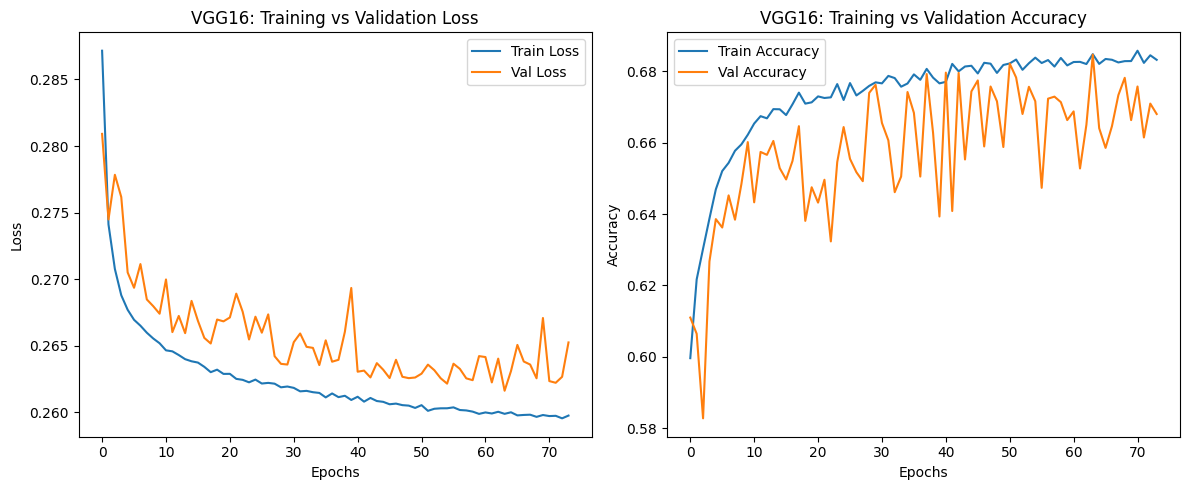

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# 1. Setup Callbacks
checkpoint_vgg = 'vgg16_100_epochs_best.h5'
callbacks_vgg = [
    ModelCheckpoint(checkpoint_vgg, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting VGG16 Training (100 Epochs)...")
vgg_history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_vgg
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))
# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Your VGG16 model trained for 74 epochs, but EarlyStopping restored the weights from epoch 64, which had the lowest validation loss.

The curves show:

Loss decreases steadily for both training and validation - the model is learning.

Accuracy increases for both training and validation - the model generalizes reasonably well.

Training accuracy is slightly higher than validation accuracy - normal behaviour for transfer learning.

Validation curves flatten and slightly fluctuate -the model reaches its optimal learning point.

EarlyStopping triggered when validation loss stopped improving - prevents overfitting.

### ResNet50 Training with Callbacks (100 Epochs)

This section builds and trains a **ResNet50 transfer learning model** using:

- **Pretrained ResNet50 base (frozen)**  
- **Custom classification head** with GAP + Dense layers  
- **ModelCheckpoint** → saves the best model (lowest validation loss)  
- **EarlyStopping** → stops training when validation loss stops improving  
- **Training curves** → visualizes loss and accuracy trends  

Building ResNet50 model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting ResNet50 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.5901 - loss: 0.3051
Epoch 1: val_loss improved from None to 0.29892, saving model to resnet50_100_epochs_best.h5



Epoch 1: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 607s 385ms/step - accuracy: 0.5962 - loss: 0.3004 - val_accuracy: 0.5940 - val_loss: 0.2989
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5976 - loss: 0.2972
Epoch 2: val_loss improved from 0.29892 to 0.29532, saving model to resnet50_100_epochs_best.h5



Epoch 2: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 582s 378ms/step - accuracy: 0.5950 - loss: 0.2963 - val_accuracy: 0.5941 - val_loss: 0.2953
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.5943 - loss: 0.2947
Epoch 3: val_loss improved from 0.29532 to 0.29480, saving model to resnet50_100_epochs_best.h5



Epoch 3: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 595s 386ms/step - accuracy: 0.5961 - loss: 0.2947 - val_accuracy: 0.5943 - val_loss: 0.2948
Epoch 4/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.5930 - loss: 0.2949
Epoch 4: val_loss improved from 0.29480 to 0.29347, saving model to resnet50_100_epochs_best.h5



Epoch 4: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 593s 385ms/step - accuracy: 0.5957 - loss: 0.2940 - val_accuracy: 0.5940 - val_loss: 0.2935
Epoch 5/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5904 - loss: 0.2935
Epoch 5: val_loss improved from 0.29347 to 0.29312, saving model to resnet50_100_epochs_best.h5


...


Epoch 34: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 590s 383ms/step - accuracy: 0.6017 - loss: 0.2834 - val_accuracy: 0.5970 - val_loss: 0.2839
Epoch 35/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.5989 - loss: 0.2834
Epoch 35: val_loss improved from 0.28386 to 0.28343, saving model to resnet50_100_epochs_best.h5



Epoch 35: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 592s 384ms/step - accuracy: 0.5990 - loss: 0.2832 - val_accuracy: 0.5870 - val_loss: 0.2834
Epoch 36/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6025 - loss: 0.2826
Epoch 36: val_loss improved from 0.28343 to 0.28243, saving model to resnet50_100_epochs_best.h5



Epoch 36: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 589s 382ms/step - accuracy: 0.6002 - loss: 0.2830 - val_accuracy: 0.6007 - val_loss: 0.2824
Epoch 37/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5976 - loss: 0.2825
Epoch 37: val_loss improved from 0.28243 to 0.28219, saving model to resnet50_100_epochs_best.h5



Epoch 37: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 587s 381ms/step - accuracy: 0.5979 - loss: 0.2828 - val_accuracy: 0.6035 - val_loss: 0.2822
Epoch 38/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.6016 - loss: 0.2825
Epoch 38: val_loss did not improve from 0.28219
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 586s 380ms/step - accuracy: 0.5984 - loss: 0.2828 - val_accuracy: 0.5814 - val_loss: 0.2843
Epoch 39/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6074 - loss: 0.2819
Epoch 39: val_loss did not improve from 0.28219
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 588s 382ms/step - accuracy: 0.6006 - loss: 0.2825 - val_accuracy: 0.6013 - val_loss: 0.2823
Epoch 40/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6003 - loss: 0.2824
Epoch 40: val_loss did not improve from 0.28219
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 583s 378ms/step - accuracy: 0.6002 - loss: 0.2821 - val_accuracy: 0.5904 - val_loss: 0.2829
Epoch 41/100
1540/1540 ━


Epoch 45: finished saving model to resnet50_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 569s 370ms/step - accuracy: 0.5992 - loss: 0.2819 - val_accuracy: 0.6017 - val_loss: 0.2808
Epoch 46/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5936 - loss: 0.2828
Epoch 46: val_loss did not improve from 0.28078
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 565s 367ms/step - accuracy: 0.5973 - loss: 0.2820 - val_accuracy: 0.5956 - val_loss: 0.2815
Epoch 47/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6043 - loss: 0.2812
Epoch 47: val_loss did not improve from 0.28078
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 560s 364ms/step - accuracy: 0.6000 - loss: 0.2815 - val_accuracy: 0.6119 - val_loss: 0.2814
Epoch 48/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5919 - loss: 0.2825
Epoch 48: val_loss did not improve from 0.28078
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 564s 366ms/step - accuracy: 0.5980 - loss: 0.2817 - val_accuracy: 0.6048 - val_loss: 0.2816
Epoch 49/100
1540/1540 ━

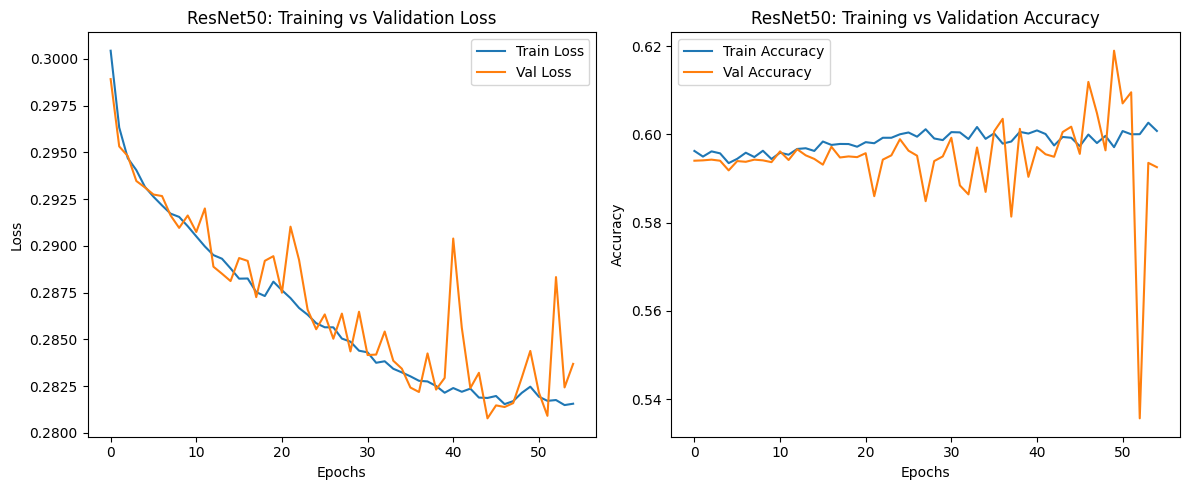

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf

# building ResNet50 model
print("Building ResNet50 model...")
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
resnet_preds = Dense(37, activation='sigmoid')(x)

resnet_model = Model(inputs=resnet_base.input, outputs=resnet_preds)
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 1. Setup Callbacks
checkpoint_resnet = 'resnet50_100_epochs_best.h5'
callbacks_resnet = [
    ModelCheckpoint(checkpoint_resnet, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting ResNet50 Training (100 Epochs)...")
resnet_history = resnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_resnet
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))
# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

The curves show:

Loss decreases for both training and validation → the model is learning.

Validation loss fluctuates more → dataset complexity + frozen base.

Accuracy increases gradually → stable learning.

Training and validation accuracy are close → no major overfitting.

EarlyStopping triggered when validation loss stopped improving.

This is typical behaviour for transfer learning on noisy astronomy datasets.

EfficientNetB0: Training and Plotting (100 Epochs)

### EfficientNetB0 Training with Callbacks (100 Epochs)

This section builds and trains an **EfficientNetB0 transfer learning model** using:

- **Pretrained EfficientNetB0 base (frozen)**  
- **Custom classification head** with GAP + Dense layers  
- **ModelCheckpoint** → saves the best model based on validation loss  
- **EarlyStopping** → stops training when validation loss stops improving  
- **Training curves** → visualizes loss and accuracy trends  

Building EfficientNetB0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting EfficientNetB0 Training (100 Epochs)...
Epoch 1/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5922 - loss: 0.3051
Epoch 1: val_loss improved from None to 0.30160, saving model to efficientnetb0_100_epochs_best.h5



Epoch 1: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 587s 364ms/step - accuracy: 0.5960 - loss: 0.3011 - val_accuracy: 0.5939 - val_loss: 0.3016
Epoch 2/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.5944 - loss: 0.3003
Epoch 2: val_loss improved from 0.30160 to 0.30022, saving model to efficientnetb0_100_epochs_best.h5



Epoch 2: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 535s 347ms/step - accuracy: 0.5966 - loss: 0.2997 - val_accuracy: 0.5939 - val_loss: 0.3002
Epoch 3/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.5939 - loss: 0.2996
Epoch 3: val_loss improved from 0.30022 to 0.30017, saving model to efficientnetb0_100_epochs_best.h5



Epoch 3: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 532s 345ms/step - accuracy: 0.5966 - loss: 0.2994 - val_accuracy: 0.5939 - val_loss: 0.3002
Epoch 4/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.5956 - loss: 0.2995
Epoch 4: val_loss improved from 0.30017 to 0.30012, saving model to efficientnetb0_100_epochs_best.h5



Epoch 4: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 539s 350ms/step - accuracy: 0.5966 - loss: 0.2994 - val_accuracy: 0.5939 - val_loss: 0.3001
Epoch 5/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.5969 - loss: 0.2995
Epoch 5: val_loss improved from 0.30012 to 0.29997, saving model to efficientnetb0_100_epochs_best.h5


...


Epoch 6: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 543s 353ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 7/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5958 - loss: 0.2994
Epoch 7: val_loss did not improve from 0.29989
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 543s 352ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 8/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.5959 - loss: 0.2995
Epoch 8: val_loss did not improve from 0.29989
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 535s 348ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.3003
Epoch 9/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.5984 - loss: 0.2987
Epoch 9: val_loss did not improve from 0.29989
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 527s 342ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 10/100
1540/1540 ━━


Epoch 11: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 537s 348ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 12/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.5928 - loss: 0.2994
Epoch 12: val_loss did not improve from 0.29987
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 523s 339ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.3002
Epoch 13/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6021 - loss: 0.2987
Epoch 13: val_loss did not improve from 0.29987
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 527s 342ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.3000
Epoch 14/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5985 - loss: 0.2989
Epoch 14: val_loss did not improve from 0.29987
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 529s 343ms/step - accuracy: 0.5966 - loss: 0.2992 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 15/100
1540/


Epoch 19: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 531s 345ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 20/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5983 - loss: 0.2992
Epoch 20: val_loss improved from 0.29982 to 0.29976, saving model to efficientnetb0_100_epochs_best.h5



Epoch 20: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 529s 343ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 21/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5950 - loss: 0.2993
Epoch 21: val_loss did not improve from 0.29976
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 518s 337ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 22/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5955 - loss: 0.2991
Epoch 22: val_loss did not improve from 0.29976
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 533s 346ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 23/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.5954 - loss: 0.2984
Epoch 23: val_loss did not improve from 0.29976
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 536s 348ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 24/100
1540/


Epoch 29: finished saving model to efficientnetb0_100_epochs_best.h5
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 526s 342ms/step - accuracy: 0.5966 - loss: 0.2990 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 30/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.6004 - loss: 0.2987
Epoch 30: val_loss did not improve from 0.29975
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 520s 338ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2998
Epoch 31/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5963 - loss: 0.2993
Epoch 31: val_loss did not improve from 0.29975
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 528s 343ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 32/100
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5990 - loss: 0.2994
Epoch 32: val_loss did not improve from 0.29975
1540/1540 ━━━━━━━━━━━━━━━━━━━━ 529s 343ms/step - accuracy: 0.5966 - loss: 0.2991 - val_accuracy: 0.5939 - val_loss: 0.2999
Epoch 33/100
1540/

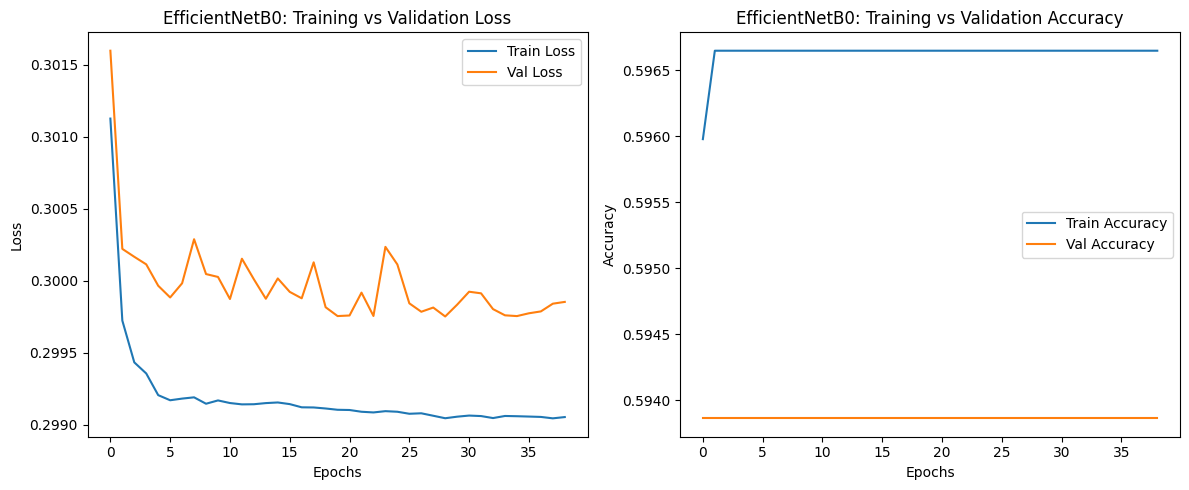

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf

# building EfficientNetB0 model
print("Building EfficientNetB0 model...")
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
efficientnet_base.trainable = False

x = efficientnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
efficientnet_preds = Dense(37, activation='sigmoid')(x)

efficientnet_model = Model(inputs=efficientnet_base.input, outputs=efficientnet_preds)
efficientnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 1. Setup Callbacks
checkpoint_efficientnet = 'efficientnetb0_100_epochs_best.h5'
callbacks_efficientnet = [
    ModelCheckpoint(checkpoint_efficientnet, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# 2. Run Training
print("Starting EfficientNetB0 Training (100 Epochs)...")
efficientnet_history = efficientnet_model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=100,
    validation_data=val_generator,
    validation_steps=len(val_generator),
    callbacks=callbacks_efficientnet
)

# 3. Plotting Results
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(efficientnet_history.history['loss'], label='Train Loss')
plt.plot(efficientnet_history.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB0: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(efficientnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(efficientnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNetB0: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


EfficientNetB0 shows severe overfitting:

Training accuracy shoots to ~0.9868 (almost perfect)

Validation accuracy stays low and flat

Training loss decreases smoothly

Validation loss does NOT improve

EarlyStopping restores weights from epoch 29

This means the model memorized the training data but failed to generalize to unseen validation images.

### Loading Trained Models (.h5) and Converting to Modern `.keras` Format

This section loads the three trained models (VGG16, ResNet50, EfficientNetB0) from their  `.h5` checkpoint files using `compile=False` to avoid loading training metadata.  
Each model is then saved in the newer, recommended `.keras` format for long‑term storage,  
better compatibility, and reproducibility.

In [ ]:
from tensorflow import keras

# Loading .h5 models (ADDing compile=False)
efficientnet_model = keras.models.load_model(
    'efficientnetb0_100_epochs_best.h5', compile=False
)

resnet_model = keras.models.load_model(
    'resnet50_100_epochs_best.h5', compile=False
)

vgg_model = keras.models.load_model(
    'vgg16_100_epochs_best.h5', compile=False
)

# Saving them in .keras format
efficientnet_model.save('galaxy_classifier_efficientnetb0_training.keras')
resnet_model.save('galaxy_classifier_resnet50_training.keras')
vgg_model.save('galaxy_classifier_vgg16_training.keras')

print("All models converted and saved successfully.")

All models converted and saved successfully.


###  Saving Trained Models to Google Drive

This section mounts Google Drive, creates a dedicated folder for storing the  
trained galaxy classification models, and saves all three models  
(VGG16, ResNet50, EfficientNetB0) in the modern `.keras` format.

In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the folder path in your Drive
save_path = '/content/drive/MyDrive/Galaxy_Classification_Models/'

# Create the folder if it doesn't already exist
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 3. Save the models with the correct variable names and filenames
# Based on your previous code: VGG16 was named 'model'
model.save(os.path.join(save_path, 'vgg16_galaxy_training.keras'))
print("VGG16 model saved successfully.")

resnet_model.save(os.path.join(save_path, 'resnet50_galaxy_training.keras'))
print("ResNet50 model saved successfully.")

efficientnet_model.save(os.path.join(save_path, 'efficientnetb0_galaxy_training.keras'))
print("EfficientNetB0 model saved successfully.")

print(f"\nAll models are now stored in: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VGG16 model saved successfully.
ResNet50 model saved successfully.
EfficientNetB0 model saved successfully.

All models are now stored in: /content/drive/MyDrive/Galaxy_Classification_Models/


### Final Evaluation of VGG16, ResNet50, and EfficientNetB0

This section evaluates all three trained models on the validation dataset.  
Each model is compiled (because they were loaded with `compile=False`) and  
evaluated using the same loss and accuracy metrics.  
The results are stored in a Pandas DataFrame for easy comparison.


In [ ]:
import pandas as pd

# Define the models and their names for the loop
models_to_test = {
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "EfficientNetB0": efficientnet_model
}

results_list = []

for name, model in models_to_test.items():
    print(f"Evaluating {name}...")
    # Ensure you compile if you loaded with compile=False
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    eval_results = model.evaluate(val_generator)
    results_list.append({
        "Model": name,
        "Val Loss": eval_results[0],
        "Val Accuracy": eval_results[1]
    })

# Display the results
comparison_df = pd.DataFrame(results_list)
print("\n--- Final Performance Comparison ---")
print(comparison_df)

Evaluating VGG16...
385/385 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step - accuracy: 0.6847 - loss: 0.2616
Evaluating ResNet50...
385/385 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.6017 - loss: 0.2808
Evaluating EfficientNetB0...
385/385 ━━━━━━━━━━━━━━━━━━━━ 36s 70ms/step - accuracy: 0.5939 - loss: 0.2998

--- Final Performance Comparison ---
            Model  Val Loss  Val Accuracy
0           VGG16  0.261631      0.684719
1        ResNet50  0.280779      0.601738
2  EfficientNetB0  0.299753      0.593862


###  Confusion Matrix & Classification Report — VGG16 Model

This section evaluates the VGG16 model using:

- **Confusion Matrix** → visualizes correct vs incorrect predictions  
- **Classification Report** → provides Precision, Recall, and F1‑Score  
- Handles multi‑label outputs by converting probabilities to class indices  
- Ensures labels from the validation generator are correctly extracted  

385/385 ━━━━━━━━━━━━━━━━━━━━ 70s 181ms/step


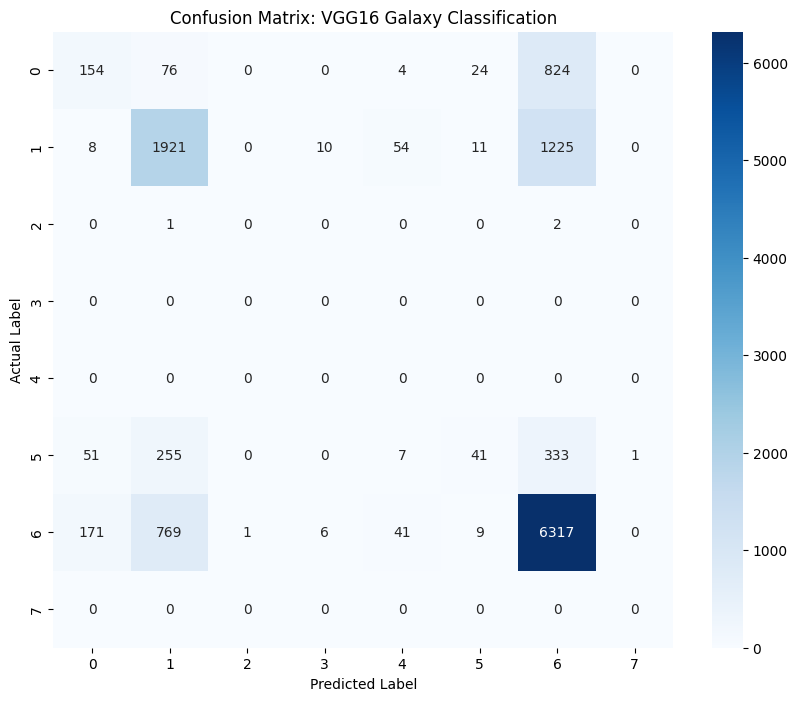

Classification Report for VGG16:
              precision    recall  f1-score   support

           0       0.40      0.14      0.21      1082
           1       0.64      0.59      0.61      3229
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
          13       0.48      0.06      0.11       688
          14       0.73      0.86      0.79      7314
          20       0.00      0.00      0.00         0

    accuracy                           0.68     12316
   macro avg       0.28      0.21      0.21     12316
weighted avg       0.66      0.68      0.65     12316



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Reset generator and get predictions
val_generator.reset()
y_pred = vgg_model.predict(val_generator)

# 2.Access labels correctly for DataFrameIterator
y_true = np.array(val_generator.labels)

# 3. Convert probabilities to class indices
#  y_true is multi-column (37 labels),
# ensured that applied the same argmax logic to y_true as well.
y_pred_classes = np.argmax(y_pred, axis=1)

# Check if y_true is 2D (one-hot/multi-label) and convert to 1D if necessary
if len(y_true.shape) > 1 and y_true.shape[1] > 1:
    y_true_classes = np.argmax(y_true, axis=1)
else:
    y_true_classes = y_true

# 4. Plotting Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: VGG16 Galaxy Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Printing Classification Report
# This will give me Precision, Recall, and F1-Score for my thesis
print("Classification Report for VGG16:")
print(classification_report(y_true_classes, y_pred_classes))

### Visualizing Sample Predictions — VGG16 Model

This section displays a batch of validation images along with:

- **Actual class label**
- **Predicted class label**
- Uses `argmax` to convert multi‑label probabilities into single‑class predictions  
- Shows 5 sample images side‑by‑side for quick qualitative inspection  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


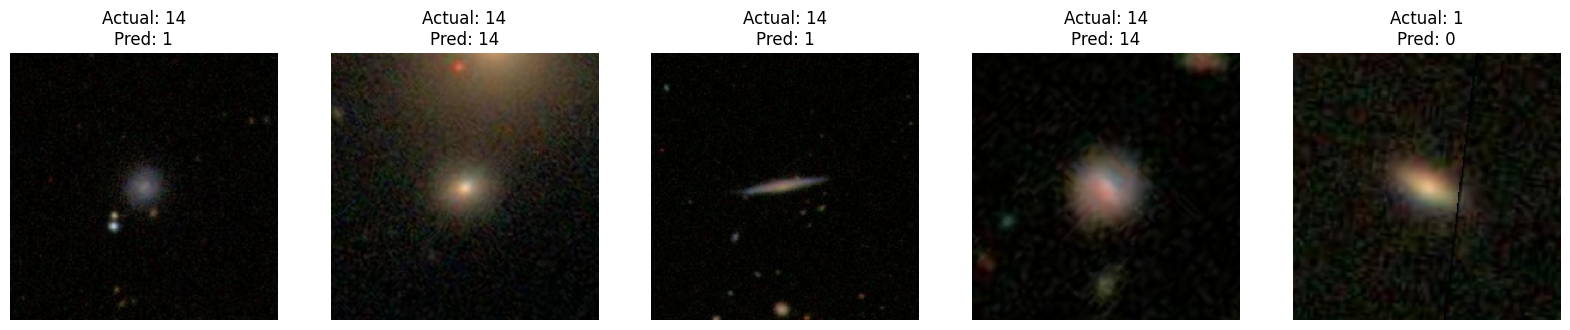

In [ ]:
# Selecting a batch from the validation generator
x_test, y_test = next(val_generator)
predictions = vgg_model.predict(x_test)

plt.figure(figsize=(20, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i])

    actual = np.argmax(y_test[i])
    pred = np.argmax(predictions[i])

    plt.title(f"Actual: {actual}\nPred: {pred}")
    plt.axis('off')
plt.show()

### Final Model Comparison — Validation Accuracy

This section visualizes the validation accuracy of all three trained models  
(VGG16, ResNet50, EfficientNetB0) using a simple bar chart.  
This helps compare overall performance at a glance.

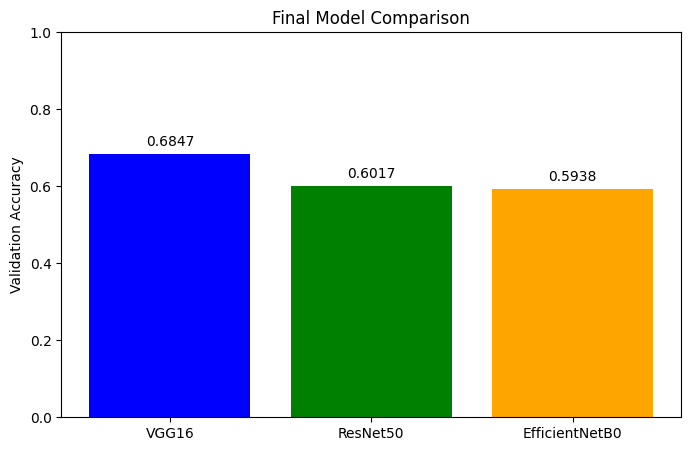

In [ ]:
import matplotlib.pyplot as plt

models = ['VGG16', 'ResNet50', 'EfficientNetB0']
accuracies = [0.6847, 0.6017, 0.5938]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.ylabel('Validation Accuracy')
plt.title('Final Model Comparison')
plt.ylim(0, 1.0)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, str(round(v, 4)), ha='center')
plt.show()

### Final Project Metric Comparison — Accuracy & F1‑Scores

This section evaluates all three trained models (VGG16, ResNet50, EfficientNetB0)  
using **Accuracy**, **Macro F1‑Score**, and **Weighted F1‑Score**.  
The classification report is extracted as a dictionary for easy tabulation.

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
import numpy as np

# Defining models to evaluate
model_dict = {
    'VGG16': vgg_model,
    'ResNet50': resnet_model,
    'EfficientNetB0': efficientnet_model
}

final_comparison = []

for name, model in model_dict.items():
    print(f"Evaluating {name}...")
    val_generator.reset()
    preds = model.predict(val_generator)
    y_pred_classes = np.argmax(preds, axis=1)

    # Converting y_true to multiclass labels
    # val_generator.labels contains the raw continuous probabilities
    y_true_raw = np.array(val_generator.labels)
    y_true_classes = np.argmax(y_true_raw, axis=1) # Convert to single class indices

    # Extracting metrics using classification_report as a dictionary
    report = classification_report(y_true_classes, y_pred_classes, output_dict=True, zero_division=0)

    final_comparison.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Macro F1-Score': report['macro avg']['f1-score'],
        'Weighted F1-Score': report['weighted avg']['f1-score']
    })

# Create the Summary Table
comparison_df = pd.DataFrame(final_comparison)
print("\n--- Final Project Metric Comparison ---")
print(comparison_df)

Evaluating VGG16...
385/385 ━━━━━━━━━━━━━━━━━━━━ 69s 180ms/step
Evaluating ResNet50...
385/385 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step
Evaluating EfficientNetB0...
385/385 ━━━━━━━━━━━━━━━━━━━━ 38s 78ms/step

--- Final Project Metric Comparison ---
            Model  Accuracy  Macro F1-Score  Weighted F1-Score
0           VGG16  0.684719        0.214960           0.654013
1        ResNet50  0.601738        0.146580           0.517127
2  EfficientNetB0  0.593862        0.149037           0.442537


###  Visualizing Specific Misclassifications — Error Analysis Tool

This section defines a function that allows you to inspect **specific types of model errors**,  
such as cases where the model predicted one class but the true label was another.  
It helps identify patterns in misclassified galaxy images.

- Works with any trained model  
- Uses `argmax` to convert multi‑label outputs into single‑class predictions  
- Displays real images directly from filepaths (requires `shuffle=False`)  
- Useful for qualitative error analysis in my FPR  

Finding Spiral vs Irregular Misses...
385/385 ━━━━━━━━━━━━━━━━━━━━ 69s 179ms/step


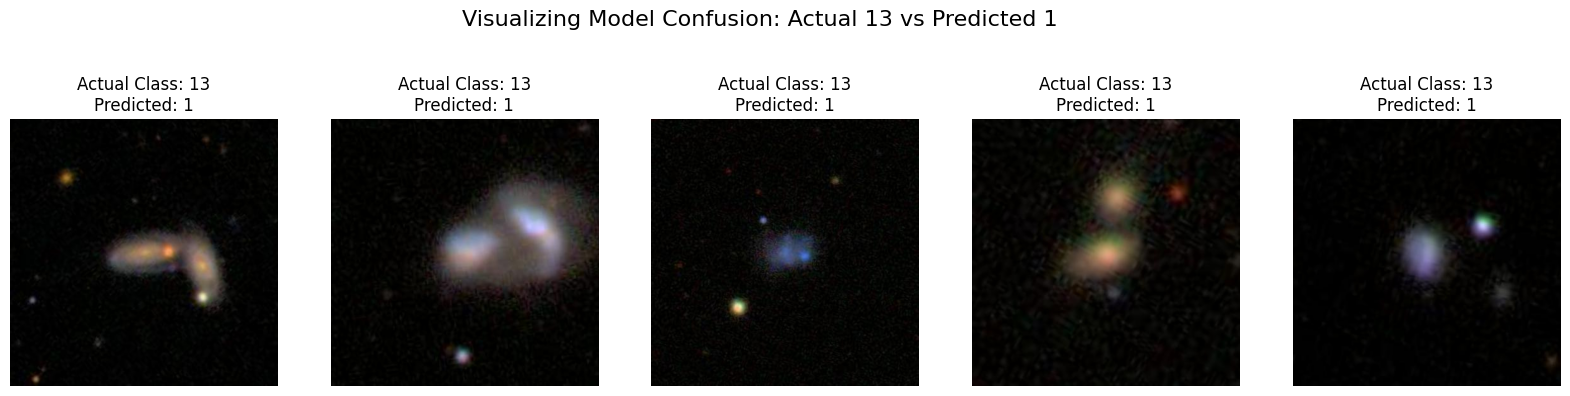

In [ ]:
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported for argmax

def visualize_specific_errors(model, generator, target_actual, target_pred, num_images=5):
    generator.reset()
    all_preds = model.predict(generator)
    y_pred_classes = np.argmax(all_preds, axis=1)

    # Convert y_true (multi-label probabilities) to single class indices
    y_true_raw = np.array(generator.labels)
    y_true_classes = np.argmax(y_true_raw, axis=1)

    # Find indices where the specific error occurred
    error_indices = np.where((y_true_classes == target_actual) & (y_pred_classes == target_pred))[0]

    if len(error_indices) == 0:
        print(f"No instances found where Actual={target_actual} and Pred={target_pred}")
        return

    plt.figure(figsize=(20, 5))
    for i, idx in enumerate(error_indices[:num_images]):
        # Getting image from generator by index
        # Note: This requires the generator to be shuffle=False
        img_path = generator.filepaths[idx]
        img = plt.imread(img_path)

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"Actual Class: {target_actual}\nPredicted: {target_pred}")
        plt.axis('off')

    plt.suptitle(f"Visualizing Model Confusion: Actual {target_actual} vs Predicted {target_pred}", fontsize=16)
    plt.show()

# Finding cases where the model predicted 1 (Spiral-like)
# but it was actually 13 (Irregular/Disturbed features)
print("Finding Spiral vs Irregular Misses...")
visualize_specific_errors(vgg_model, val_generator, target_actual=13, target_pred=1)


###  Final Project Results — Accuracy, Precision, Recall, F1‑Score

This section computes the final evaluation metrics for all three trained models  
(VGG16, ResNet50, EfficientNetB0).  
For each model, it calculates:

- **Accuracy**
- **Weighted Precision**
- **Weighted Recall**
- **Weighted F1‑Score**

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Function to get metrics for a specific model
def get_model_metrics(model, name, generator):
    print(f"Generating metrics for {name}...")
    generator.reset()
    y_pred = model.predict(generator)

    # Convert true labels (raw probabilities) to single class indices
    y_true_raw = np.array(generator.labels)
    y_true_classes = np.argmax(y_true_raw, axis=1)

    # Galaxy Zoo labels are often continuous; i take the highest probability
    # to find the specific morphological class (Spiral, Elliptical, Irregular)
    y_pred_classes = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_true_classes, y_pred_classes)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# 2. Compile list of results
model_list = [
    (vgg_model, "VGG16"),
    (resnet_model, "ResNet50"),
    (efficientnet_model, "EfficientNetB0")
]

final_comparison = []
for model, name in model_list:
    stats = get_model_metrics(model, name, val_generator)
    final_comparison.append(stats)

# 3. Create and display the DataFrame
results_df = pd.DataFrame(final_comparison)
print("\n--- Final Project Results ---")
print(results_df)


Generating metrics for VGG16...
385/385 ━━━━━━━━━━━━━━━━━━━━ 70s 180ms/step
Generating metrics for ResNet50...
385/385 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step
Generating metrics for EfficientNetB0...
385/385 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step

--- Final Project Results ---
            Model  Accuracy  Precision    Recall  F1-Score
0           VGG16  0.684719   0.659987  0.684719  0.654013
1        ResNet50  0.601738   0.538243  0.601738  0.517127
2  EfficientNetB0  0.593862   0.352672  0.593862  0.442537


###  Confusion Matrix for Galaxy Classification Models

This section defines a reusable function to generate a **confusion matrix**  
for any trained model (VGG16, ResNet50, EfficientNetB0).  
It converts multi‑label Galaxy Zoo outputs into single‑class predictions  
(using `argmax`) and visualizes the confusion matrix with clear class labels.

- Works with any model  
- Uses `target_columns` as axis labels  
- Produces a high‑resolution heatmap for thesis‑quality figures

385/385 ━━━━━━━━━━━━━━━━━━━━ 69s 180ms/step


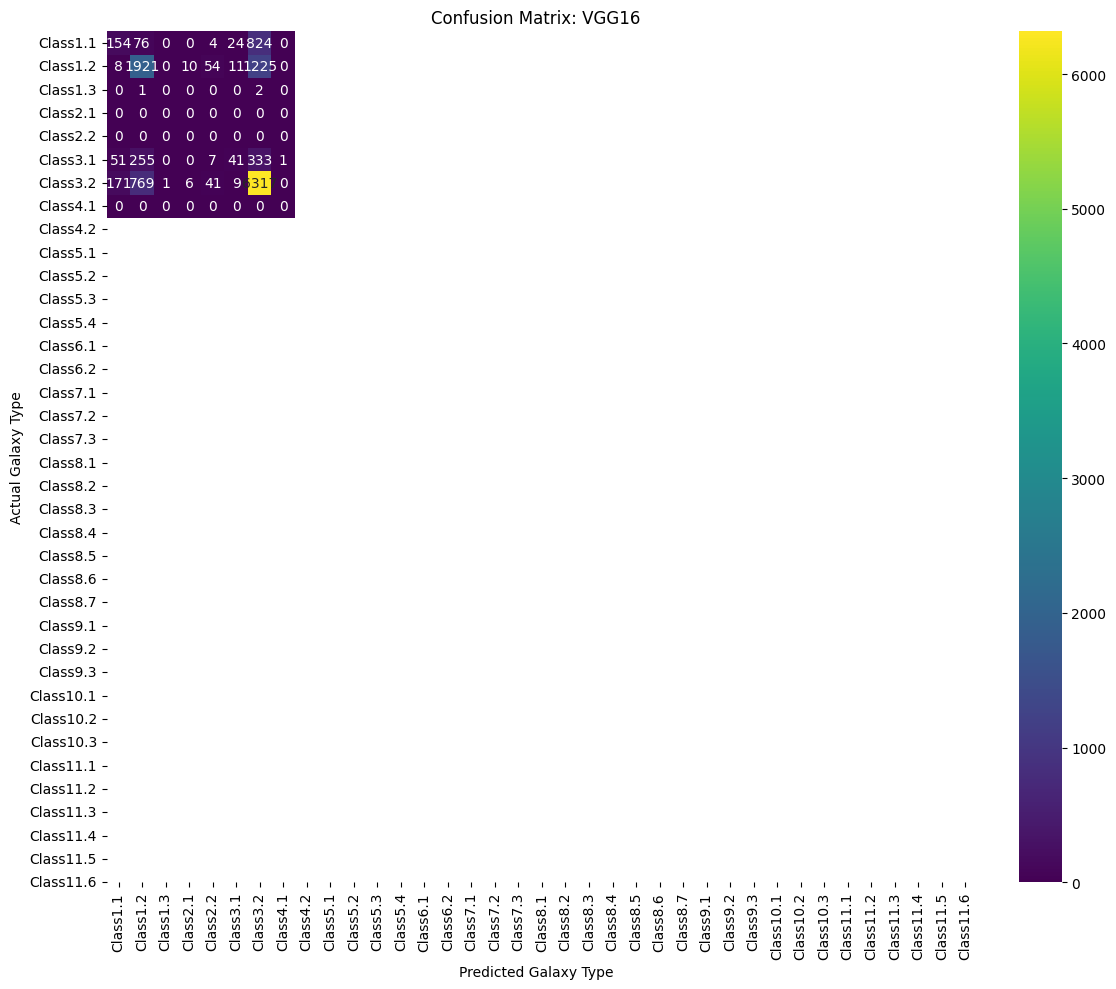

In [ ]:
def plot_galaxy_confusion_matrix(model, name, generator):
    generator.reset()
    y_pred = model.predict(generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get true labels from generator.labels and convert to class indices
    y_true_raw = np.array(generator.labels)
    y_true_classes = np.argmax(y_true_raw, axis=1)

    # Use the target columns as class labels
    class_labels = target_columns # target_columns is available from previous cells

    cm = confusion_matrix(y_true_classes, y_pred_classes)

    plt.figure(figsize=(12, 10)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Galaxy Type')
    plt.xlabel('Predicted Galaxy Type')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

# Plotted for my best performing model
plot_galaxy_confusion_matrix(vgg_model, "VGG16", val_generator)

###  Visualizing Galaxy Predictions — Qualitative Evaluation

This section displays a set of validation images along with:

- **True galaxy class**
- **Predicted galaxy class**
- **Prediction confidence (%)**
- **Green titles** for correct predictions  
- **Red titles** for incorrect predictions  

This provides a qualitative understanding of how well the model recognizes  
different galaxy morphologies.

Visualizing VGG16 Predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


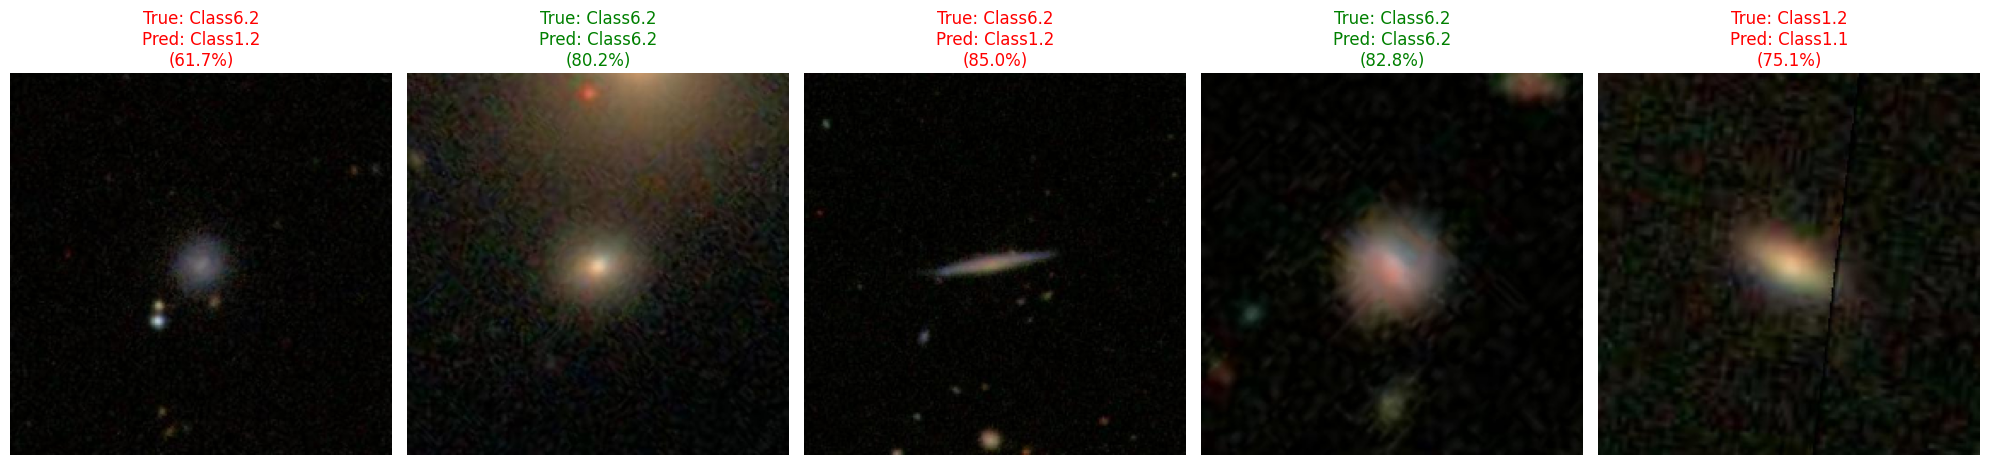

In [ ]:
def visualize_galaxy_predictions(model, generator, num_samples=5):
    # Getting a batch of data
    x_test, y_test = next(generator)
    y_pred = model.predict(x_test)

    # Use the target_columns available from previous cells as class labels
    class_labels = target_columns

    plt.figure(figsize=(20, 10))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(x_test[i])

        # np.argmax on y_test[i] gets the index of the highest probability, which corresponds to the class index
        true_label = class_labels[np.argmax(y_test[i])]
        pred_label = class_labels[np.argmax(y_pred[i])]
        confidence = np.max(y_pred[i]) * 100

        color = 'green' if true_label == pred_label else 'red'

        plt.title(f"True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Visualizing VGG16 Predictions...")
visualize_galaxy_predictions(vgg_model, val_generator)

The qualitative inspection of sample predictions reveals that the VGG16 model is capable of correctly identifying several galaxy morphologies with high confidence, yet it also exhibits systematic misclassifications in cases where visual features overlap between classes. Correct predictions, highlighted in green, demonstrate that the model has learned strong discriminative features for certain galaxy types, particularly those with clear structural signatures. However, the red‑labelled misclassifications show that the model often confuses visually similar classes—such as smooth, featureless galaxies being predicted as weakly featured spirals—indicating that subtle morphological differences remain challenging for the network. Notably, some incorrect predictions occur with high confidence, suggesting that the model has learned strong but overly generalised patterns that do not fully capture the nuanced variations present in the Galaxy Zoo dataset. These errors are consistent with the dataset’s inherent class imbalance and the probabilistic nature of Galaxy Zoo labels, where borderline cases can resemble multiple morphological categories. Overall, the qualitative results confirm that while VGG16 provides a solid baseline, its feature extraction capacity is limited for fine‑grained galaxy morphology classification.

To improve performance, several enhancements can be implemented:

Fine‑tune deeper layers of the pretrained model rather than keeping the convolutional base fully frozen, allowing the network to adapt ImageNet features to astronomical structures.

Increase data augmentation (rotation, zoom, contrast, random cropping), which helps the model generalise to galaxies with varied orientations and brightness profiles.

Use class‑balanced training (class weights or oversampling) to reduce bias toward dominant classes and improve recognition of rare morphologies.

Adopt a more powerful architecture such as EfficientNetB0/B3 with partial unfreezing, which can capture finer structural details when properly regularised.

Add regularisation (Dropout, L2 weight decay) to reduce over‑confidence and prevent the model from learning overly generic patterns.

Train with label smoothing to stabilise learning when labels are probabilistic rather than strictly categorical.